In [1]:
import sys
from pathlib import Path

current_dir = Path.cwd()

def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'pyproject.toml').exists() and (p / 'bcosgnn').is_dir():
            return p
    raise RuntimeError('Could not locate repo root (pyproject.toml + bcosgnn/).')

project_root = find_repo_root(current_dir)

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print(f"Repo root added: {project_root}")

Repo root added: /home/moso00002/Desktop/gnn/bcosgnn-bcos_gnn_shaique


In [2]:
import sys
import os

import functools
import itertools
import operator
from typing import Any
import torch
from torch_geometric.data import Dataset, download_url
from torch.utils.data import random_split
import numpy as np
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
import torch
from bcos.modules import BcosLinear, BcosSequential
from sklearn.model_selection import train_test_split
from torch.nn import BCEWithLogitsLoss
from torch_geometric.datasets import BA2MotifDataset
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import MessagePassing
from torch_geometric.nn.aggr import SumAggregation
from torch_geometric.utils import add_self_loops, degree
from torchmetrics import AUROC
from torchmetrics.classification import BinaryAccuracy
from tqdm import tqdm
import networkx as nx
import matplotlib.pyplot as plt
import torch.nn.functional as F
from bcosgnn.explain import explain
import tqdm

## Dataset loading

In [3]:
import torch
import os
from torch.utils.data import random_split
from torch_geometric.loader import DataLoader


raw_data_path = "/home/moso00002/Desktop/gnn/bcosgnn-bcos_gnn_shaique/shaique_updates/data/Custom_BA2Motif/custom_ba2motif_dataset.pt"
print(f"Loading data directly from: {raw_data_path}")



dataset_list = torch.load(raw_data_path, weights_only=False)
print(f"Successfully loaded {len(dataset_list)} graphs.")

for i, data in enumerate(dataset_list):
    data.y = torch.tensor([0]) if i < 500 else torch.tensor([1])
    data.x = torch.ones((data.num_nodes, 1))

first_graph = dataset_list[0]
num_features = first_graph.num_features
all_labels = torch.cat([d.y for d in dataset_list])
num_classes = len(all_labels.unique())

print(f'Number of graphs: {len(dataset_list)}')
print(f'Number of features: {num_features}')
print(f'Number of classes: {num_classes}')


train_split_idx, test_split_idx = train_test_split(
    np.arange(len(dataset_list)), test_size=0.2, train_size=0.8, random_state=42
)

train_dataset = [dataset_list[i] for i in train_split_idx]
test_dataset = [dataset_list[i] for i in test_split_idx]

print(f"Training set size: {len(train_dataset)}")
print(f"Test set size: {len(test_dataset)}")

Loading data directly from: /home/moso00002/Desktop/gnn/bcosgnn-bcos_gnn_shaique/shaique_updates/data/Custom_BA2Motif/custom_ba2motif_dataset.pt
Successfully loaded 1000 graphs.
Number of graphs: 1000
Number of features: 1
Number of classes: 2
Training set size: 800
Test set size: 200


In [4]:
def get_one_hot_degree_clamped(data, max_degree=4):
    row, col = data.edge_index
    deg = degree(col, data.num_nodes, dtype=torch.long)
    deg = deg.clamp(max=max_degree)
    one_hot_deg = torch.nn.functional.one_hot(deg, num_classes=max_degree + 1).to(
        torch.float
    )
    data.x = one_hot_deg.float()
    return data

  Graph Index 0: Node Mask = [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 1. 1. 1. 1. 1.]
  Graph Index 1: Node Mask = [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 1. 1. 1. 1. 1.]
  Graph Index 2: Node Mask = [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 1. 1. 1. 1. 1.]
  Graph Index 3: Node Mask = [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 1. 1. 1. 1. 1.]
  Graph Index 4: Node Mask = [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 1. 1. 1. 1. 1.]
  Graph Index 5: Node Mask = [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 1. 1. 1. 1. 1.]
  Graph Index 6: Node Mask = [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 1. 1. 1. 1. 1.]
  Graph Index 7: Node Mask = [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 1. 1. 1. 1. 1.]
  Graph Index 8: Node Ma

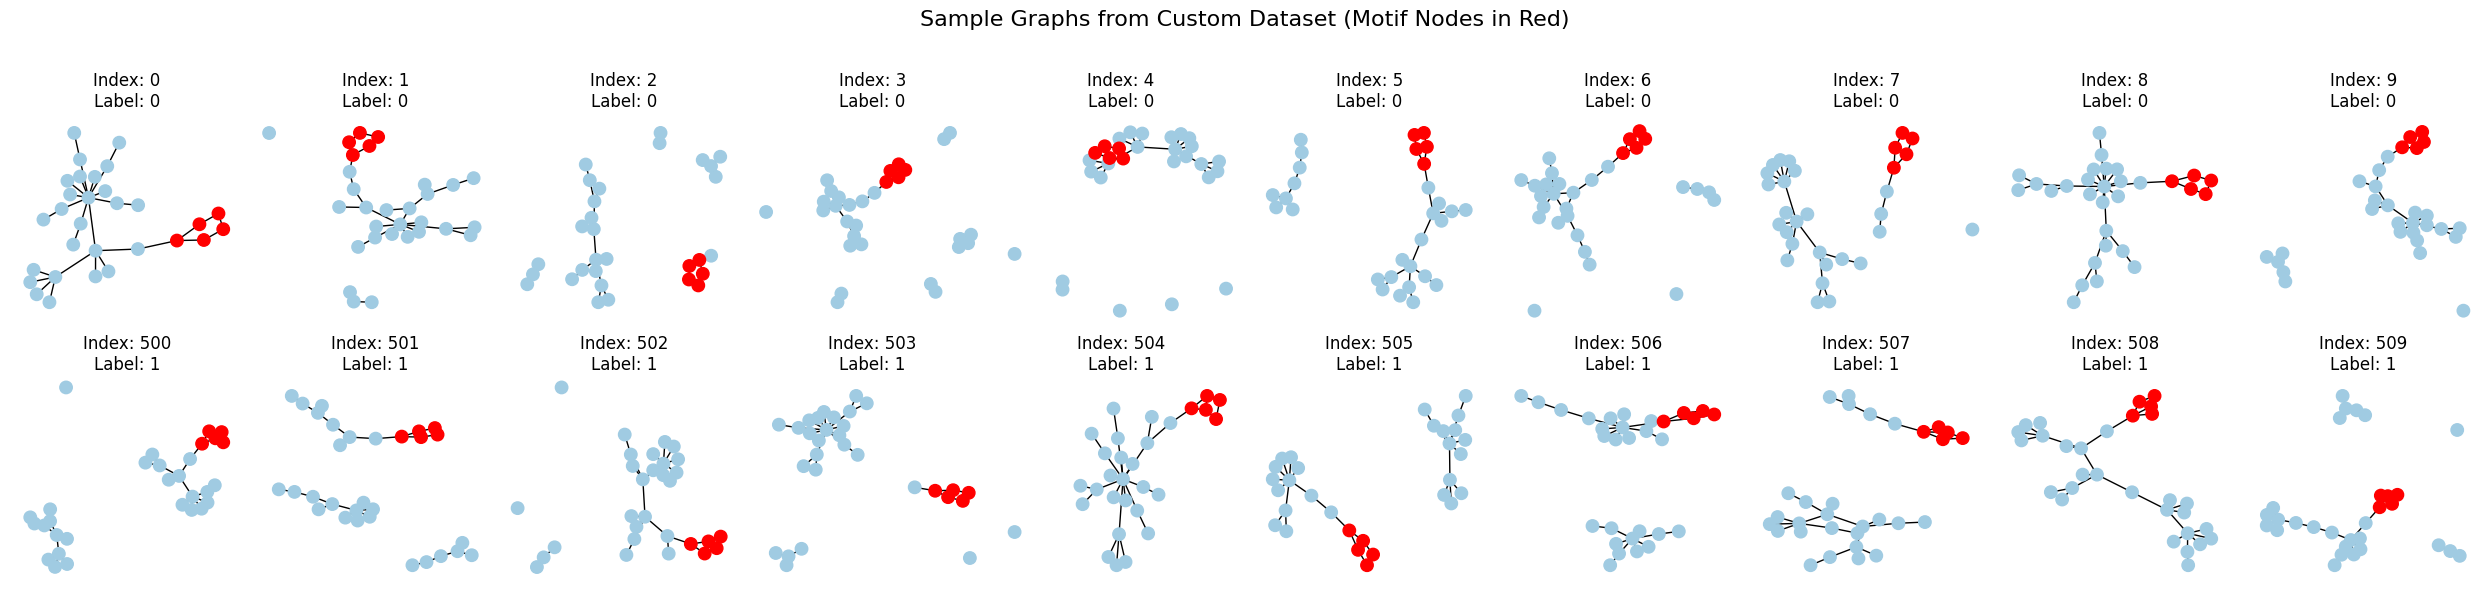

In [5]:
import networkx as nx
import matplotlib.pyplot as plt


class_0_samples = []
class_1_samples = []

for i, data in enumerate(dataset_list):
    if data.y.item() == 0 and len(class_0_samples) < 10:
        class_0_samples.append((i, data))
    elif data.y.item() == 1 and len(class_1_samples) < 10:
        class_1_samples.append((i, data))
    
    if len(class_0_samples) == 10 and len(class_1_samples) == 10:
        break

fig, axes = plt.subplots(2, 10, figsize=(25, 6))
fig.suptitle("Sample Graphs from Custom Dataset (Motif Nodes in Red)", fontsize=16)

#  Class 0 (Cycle Motif) 
for i, (original_index, data) in enumerate(class_0_samples):
    print(f"  Graph Index {original_index}: Node Mask = {data.node_mask.numpy().ravel()}")
    
    g = nx.Graph()
    g.add_nodes_from(range(data.num_nodes))
    g.add_edges_from(data.edge_index.t().tolist())
    
    node_colors = ['red' if mask == 1 else '#A0CBE2' for mask in data.node_mask]
    
    ax = axes[0, i]
    pos = nx.spring_layout(g, seed=42)
    nx.draw(g, pos, ax=ax, with_labels=False, node_color=node_colors, node_size=80)
    ax.set_title(f"Index: {original_index}\nLabel: 0")

#  Class 1 (House Motif) 
for i, (original_index, data) in enumerate(class_1_samples):
    print(f"  Graph Index {original_index}: Node Mask = {data.node_mask.numpy().ravel()}")
    
    g = nx.Graph()
    g.add_nodes_from(range(data.num_nodes))
    g.add_edges_from(data.edge_index.t().tolist())
    
    node_colors = ['red' if mask == 1 else '#A0CBE2' for mask in data.node_mask]
    
    ax = axes[1, i]
    pos = nx.spring_layout(g, seed=42)
    nx.draw(g, pos, ax=ax, with_labels=False, node_color=node_colors, node_size=80)
    ax.set_title(f"Index: {original_index}\nLabel: 1")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [6]:
import torch.nn.functional as F
from torch.nn import Sequential, Linear, ReLU, BatchNorm1d
from torch_geometric.nn import GINConv, global_add_pool

import torch.nn.functional as F
from torch.nn import Sequential, Linear, ReLU, BatchNorm1d
from torch_geometric.nn import GINConv, global_add_pool

class GINNodeClassifier(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        
        super(GINNodeClassifier, self).__init__()

        self.conv1 = GINConv(Sequential(Linear(in_channels, hidden_channels) , BatchNorm1d(hidden_channels), ReLU(), Linear(hidden_channels, hidden_channels), ReLU()))

        self.bn1 = BatchNorm1d(hidden_channels)

        self.conv2 = GINConv(Sequential(Linear(hidden_channels, hidden_channels) , BatchNorm1d(hidden_channels), ReLU(), Linear(hidden_channels, hidden_channels), ReLU()))

        self.bn2 = BatchNorm1d(hidden_channels)

        self.conv3 = GINConv(Sequential(Linear(hidden_channels, hidden_channels) , BatchNorm1d(hidden_channels), ReLU(), Linear(hidden_channels, hidden_channels), ReLU()))

        self.bn3 = BatchNorm1d(hidden_channels)

        self.conv4 = GINConv(Sequential(Linear(hidden_channels, hidden_channels) , BatchNorm1d(hidden_channels), ReLU(), Linear(hidden_channels, hidden_channels), ReLU()))

        self.bn4 = BatchNorm1d(hidden_channels)

        self.classifier = Linear(hidden_channels, out_channels)

    def forward(self, x, edge_index , batch):

        x = x.float()

        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.conv3(x, edge_index)
        x = self.bn3(x)
        x = F.relu(x)
        x = self.conv4(x, edge_index)
        x = self.bn4(x)
        x = F.relu(x)

        x = global_add_pool(x, batch)

        return self.classifier(x)

model = GINNodeClassifier(in_channels=1, hidden_channels=64, out_channels=2)
print(model)

GINNodeClassifier(
  (conv1): GINConv(nn=Sequential(
    (0): Linear(in_features=1, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): ReLU()
  ))
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): GINConv(nn=Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): ReLU()
  ))
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): GINConv(nn=Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=

In [7]:
train_data = [get_one_hot_degree_clamped(data) for data in train_dataset]
test_data = [get_one_hot_degree_clamped(data) for data in test_dataset]

print("Number of training graphs after feature transformation:", len(train_data))
print("Number of testing graphs after feature transformation:", len(test_data))

Number of training graphs after feature transformation: 800
Number of testing graphs after feature transformation: 200


Training on 800 graphs for 200 epochs...
Epoch 010 | Train Loss: 0.0001 | Train Acc: 1.0000
Epoch 010 | Train Loss: 0.0001 | Train Acc: 1.0000
Epoch 020 | Train Loss: 0.0035 | Train Acc: 0.9975
Epoch 020 | Train Loss: 0.0035 | Train Acc: 0.9975
Epoch 030 | Train Loss: 0.0000 | Train Acc: 1.0000
Epoch 030 | Train Loss: 0.0000 | Train Acc: 1.0000
Epoch 040 | Train Loss: 0.0000 | Train Acc: 1.0000
Epoch 040 | Train Loss: 0.0000 | Train Acc: 1.0000
Epoch 050 | Train Loss: 0.0000 | Train Acc: 1.0000
Epoch 050 | Train Loss: 0.0000 | Train Acc: 1.0000
Epoch 060 | Train Loss: 0.0000 | Train Acc: 1.0000
Epoch 060 | Train Loss: 0.0000 | Train Acc: 1.0000
Epoch 070 | Train Loss: 0.0000 | Train Acc: 1.0000
Epoch 070 | Train Loss: 0.0000 | Train Acc: 1.0000
Epoch 080 | Train Loss: 0.0000 | Train Acc: 1.0000
Epoch 080 | Train Loss: 0.0000 | Train Acc: 1.0000
Epoch 090 | Train Loss: 0.0007 | Train Acc: 1.0000
Epoch 090 | Train Loss: 0.0007 | Train Acc: 1.0000
Epoch 100 | Train Loss: 0.0001 | Train Ac

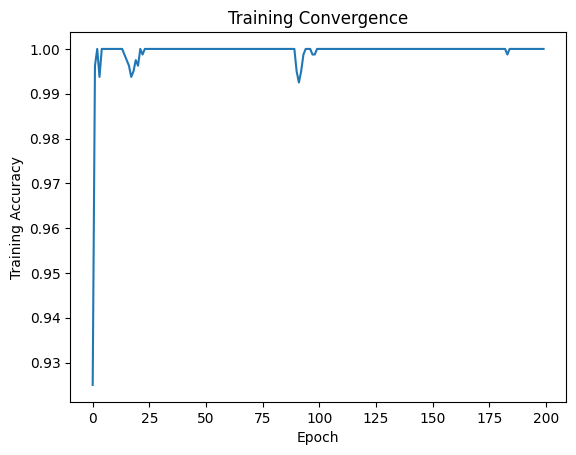

In [8]:
import torch
import torch.nn.functional as F
from torch_geometric.loader import DataLoader
import matplotlib.pyplot as plt

# 1. Setup Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Data Preparation
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
# Test loader is ready, but we won't touch it until the end
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

# 3. Model Setup
# Check feature dimension from the first graph
input_dim = train_data[0].x.shape[1] 

model = GINNodeClassifier(in_channels=input_dim, hidden_channels=64, out_channels=2)
model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# 4. Define Train and Test Steps
def train_epoch():
    model.train()
    total_loss = 0
    total_correct = 0
    total_graphs = 0
    
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        
        # Pass batch vector for global pooling
        out = model(data.x, data.edge_index, data.batch)
        
        loss = F.cross_entropy(out, data.y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * data.num_graphs
        pred = out.argmax(dim=1)
        total_correct += int((pred == data.y).sum())
        total_graphs += data.num_graphs

    return total_loss / total_graphs, total_correct / total_graphs

@torch.no_grad()
def test_step(loader):
    model.eval()
    total_correct = 0
    total_graphs = 0
    for data in loader:
        data = data.to(device)
        out = model(data.x, data.edge_index, data.batch)
        pred = out.argmax(dim=1)
        total_correct += int((pred == data.y).sum())
        total_graphs += data.num_graphs
        
    return total_correct / total_graphs

# 5. Execution: Train Completely First
print(f"Training on {len(train_data)} graphs for 200 epochs...")
train_accs = []

for epoch in range(1, 201):
    loss, acc = train_epoch()
    train_accs.append(acc)
    
    if epoch % 10 == 0:
        print(f'Epoch {epoch:03d} | Train Loss: {loss:.4f} | Train Acc: {acc:.4f}')

# 6. Final Evaluation: Test Once
print("\nTraining complete. Evaluating on held-out Test Set...")
final_test_acc = test_step(test_loader)

print(f"Final Test Accuracy: {final_test_acc:.4f}")

# Optional: Visualize training convergence
plt.plot(train_accs)
plt.xlabel('Epoch')
plt.ylabel('Training Accuracy')
plt.title('Training Convergence')
plt.show()

In [ ]:
from torch_geometric.explain import Explainer, GNNExplainer
from sklearn.metrics import jaccard_score, roc_auc_score
import numpy as np
from tqdm import tqdm
import torch

# NOTE: Your ground-truth motif is: nodes where `data.node_mask == 1`.

# Run on CPU (more stable than CUDA for explainers + better tracebacks)
explanation_device = torch.device('cpu')
print(f"Running explanation on: {explanation_device}")

model = model.to(explanation_device)
model.eval()

explainer = Explainer(
    model=model,
    algorithm=GNNExplainer(epochs=200),
    explanation_type='model',
    node_mask_type='object',
    edge_mask_type='object',
    model_config=dict(
        mode='multiclass_classification',
        task_level='graph',
        return_type='raw',
    ),
)

def _reduce_node_mask_to_scores(node_mask: np.ndarray) -> np.ndarray:
    # node_mask can be [num_nodes], [num_nodes, 1], or [num_nodes, F]
    if node_mask.ndim == 2:
        node_mask = node_mask.mean(axis=1)
    return node_mask.reshape(-1)


def _coalesce_directed_to_undirected(edge_index: torch.Tensor, edge_weight: np.ndarray, num_nodes: int):
    """Coalesce (u->v) and (v->u) into an undirected edge by taking max weight.

    Returns arrays (u, v, w) with u <= v.
    """
    src = edge_index[0].detach().cpu().numpy()
    dst = edge_index[1].detach().cpu().numpy()
    w = edge_weight.reshape(-1).astype(np.float64)

    u = np.minimum(src, dst)
    v = np.maximum(src, dst)
    key = u.astype(np.int64) * np.int64(num_nodes) + v.astype(np.int64)

    order = np.argsort(key)
    key = key[order]
    u = u[order]
    v = v[order]
    w = w[order]

    uniq_key, start_idx = np.unique(key, return_index=True)
    w_max = np.maximum.reduceat(w, start_idx)
    u_uniq = u[start_idx]
    v_uniq = v[start_idx]
    return u_uniq, v_uniq, w_max


def _node_scores_from_edge_mask(edge_index: torch.Tensor, edge_mask: np.ndarray, num_nodes: int, mode: str) -> np.ndarray:
    """Aggregate edge importances into node scores.

    mode:
      - 'sum': sum of incident edge weights
      - 'mean': mean incident weight (sum/deg) to reduce hub bias
      - 'max': max incident weight (often better for compact motifs)

    We first coalesce directed edges into undirected (max), so duplicates don't overweight.
    """
    u, v, w = _coalesce_directed_to_undirected(edge_index, edge_mask, num_nodes)

    scores_sum = np.zeros(num_nodes, dtype=np.float64)
    deg = np.zeros(num_nodes, dtype=np.float64)

    np.add.at(scores_sum, u, w)
    np.add.at(scores_sum, v, w)
    np.add.at(deg, u, 1.0)
    np.add.at(deg, v, 1.0)

    if mode == 'sum':
        return scores_sum
    if mode == 'mean':
        return scores_sum / np.maximum(deg, 1.0)
    if mode == 'max':
        scores_max = np.zeros(num_nodes, dtype=np.float64)
        np.maximum.at(scores_max, u, w)
        np.maximum.at(scores_max, v, w)
        return scores_max

    raise ValueError(f"Unknown mode: {mode}")


def _eval_scores_against_gt(node_scores: np.ndarray, gt_mask: np.ndarray):
    out = {}

    if len(np.unique(gt_mask)) > 1:
        try:
            out['auroc'] = float(roc_auc_score(gt_mask, node_scores))
        except ValueError:
            out['auroc'] = None
    else:
        out['auroc'] = None

    k = int(gt_mask.sum())
    if k > 0:
        top_k = np.argsort(node_scores)[-k:]
        pred = np.zeros_like(node_scores, dtype=np.int64)
        pred[top_k] = 1
        out['jaccard'] = float(jaccard_score(gt_mask, pred))
    else:
        out['jaccard'] = None

    return out


def _eval_edge_scores_against_gt(u: np.ndarray, v: np.ndarray, w: np.ndarray, gt_edge: np.ndarray):
    """Edge AUROC + Jaccard@TopM, where M is number of GT positive edges."""
    out = {}
    gt_edge = gt_edge.astype(np.int64).reshape(-1)
    w = w.reshape(-1)

    if len(np.unique(gt_edge)) > 1:
        try:
            out['auroc'] = float(roc_auc_score(gt_edge, w))
        except ValueError:
            out['auroc'] = None
    else:
        out['auroc'] = None

    m = int(gt_edge.sum())
    if m > 0:
        top_m = np.argsort(w)[-m:]
        pred = np.zeros_like(w, dtype=np.int64)
        pred[top_m] = 1
        out['jaccard'] = float(jaccard_score(gt_edge, pred))
    else:
        out['jaccard'] = None

    return out


num_samples = 50
print(f"Explaining first {num_samples} graphs in test set...")

# Node-mask metrics
jaccard_node_all, auroc_node_all = [], []

# Edge-mask -> node metrics (three aggregation modes)
edge_modes = ['sum', 'mean', 'max']
edge_node_metrics = {mode: {'jaccard': [], 'auroc': []} for mode in edge_modes}

# Edge-mask metrics evaluated directly on edges, with GT edges derived from node_mask
edge_edge_metrics = {
    'internal': {'jaccard': [], 'auroc': []},  # edge is positive if BOTH endpoints are motif nodes
    'touching': {'jaccard': [], 'auroc': []},  # edge is positive if ANY endpoint is a motif node
}

num_skipped_no_gt = 0
num_skipped_bad_graph = 0
num_skipped_k0 = 0
num_correct = 0
ks = []

for i, data in enumerate(tqdm(test_data[:num_samples])):
    if data.x.size(0) != data.num_nodes:
        num_skipped_bad_graph += 1
        continue
    if data.edge_index.numel() > 0:
        if data.edge_index.min() < 0 or data.edge_index.max() >= data.num_nodes:
            num_skipped_bad_graph += 1
            continue

    if not hasattr(data, 'node_mask'):
        num_skipped_no_gt += 1
        continue

    data = data.to(explanation_device)
    batch = torch.zeros(data.num_nodes, dtype=torch.long, device=explanation_device)

    target = int(data.y.view(-1)[0].item())

    with torch.no_grad():
        logits = model(data.x, data.edge_index, batch)
        pred = int(logits.argmax(dim=-1).view(-1)[0].item())
        if pred == target:
            num_correct += 1

    gt_nodes = data.node_mask
    if gt_nodes.dim() > 1:
        gt_nodes = gt_nodes.view(-1)
    gt_nodes = (gt_nodes > 0.5).to(torch.int64).detach().cpu().numpy()

    k = int(gt_nodes.sum())
    if k <= 0:
        num_skipped_k0 += 1
        continue
    ks.append(k)

    try:
        explanation = explainer(
            x=data.x,
            edge_index=data.edge_index,
            batch=batch,
            target=target,
        )
    except Exception as e:
        print(f"Error explaining Graph {i}: {e}")
        continue

    # ---- Node-mask based scores ----
    if explanation.node_mask is not None:
        node_scores = _reduce_node_mask_to_scores(explanation.node_mask.detach().cpu().numpy())
        m = _eval_scores_against_gt(node_scores, gt_nodes)
        if m['jaccard'] is not None:
            jaccard_node_all.append(m['jaccard'])
        if m['auroc'] is not None:
            auroc_node_all.append(m['auroc'])

    # ---- Edge-mask metrics ----
    if explanation.edge_mask is not None:
        edge_mask = explanation.edge_mask.detach().cpu().numpy()

        # Edge -> node scoring (aggregation)
        for mode in edge_modes:
            node_scores_from_edges = _node_scores_from_edge_mask(data.edge_index, edge_mask, data.num_nodes, mode=mode)
            m2 = _eval_scores_against_gt(node_scores_from_edges, gt_nodes)
            if m2['jaccard'] is not None:
                edge_node_metrics[mode]['jaccard'].append(m2['jaccard'])
            if m2['auroc'] is not None:
                edge_node_metrics[mode]['auroc'].append(m2['auroc'])

        # Direct edge evaluation: coalesce to undirected edges, then derive GT edges from node GT
        u, v, w = _coalesce_directed_to_undirected(data.edge_index, edge_mask, data.num_nodes)
        gt_internal = (gt_nodes[u] == 1) & (gt_nodes[v] == 1)
        gt_touching = (gt_nodes[u] == 1) | (gt_nodes[v] == 1)

        e1 = _eval_edge_scores_against_gt(u, v, w, gt_internal)
        e2 = _eval_edge_scores_against_gt(u, v, w, gt_touching)

        if e1['jaccard'] is not None:
            edge_edge_metrics['internal']['jaccard'].append(e1['jaccard'])
        if e1['auroc'] is not None:
            edge_edge_metrics['internal']['auroc'].append(e1['auroc'])

        if e2['jaccard'] is not None:
            edge_edge_metrics['touching']['jaccard'].append(e2['jaccard'])
        if e2['auroc'] is not None:
            edge_edge_metrics['touching']['auroc'].append(e2['auroc'])

print("\n--- Diagnostics ---")
print(f"Graphs processed: {min(num_samples, len(test_data))}")
print(f"Skipped (no node_mask GT): {num_skipped_no_gt}")
print(f"Skipped (bad graph structure): {num_skipped_bad_graph}")
print(f"Skipped (k==0 motif nodes): {num_skipped_k0}")
print(f"Correct predictions among evaluated graphs: {num_correct} / {max(1, len(ks))}")
if len(ks) > 0:
    print(f"Motif size k: mean={np.mean(ks):.2f}, min={np.min(ks)}, max={np.max(ks)}")

print("\n--- Evaluation (NodeMask scores; node-level) ---")
print(f"Mean Jaccard (all): {np.mean(jaccard_node_all) if len(jaccard_node_all)>0 else 'N/A'}")
print(f"Mean AUROC   (all): {np.mean(auroc_node_all) if len(auroc_node_all)>0 else 'N/A'}")

print("\n--- Evaluation (EdgeMask -> Node scores; node-level) ---")
for mode in edge_modes:
    j = edge_node_metrics[mode]['jaccard']
    a = edge_node_metrics[mode]['auroc']
    print(f"Aggregation={mode:>4} | Mean Jaccard: {np.mean(j) if len(j)>0 else 'N/A'} | Mean AUROC: {np.mean(a) if len(a)>0 else 'N/A'}")

print("\n--- Evaluation (EdgeMask directly; edge-level) ---")
for kind in ['internal', 'touching']:
    j = edge_edge_metrics[kind]['jaccard']
    a = edge_edge_metrics[kind]['auroc']
    print(f"GT edges={kind:>8} | Mean Jaccard: {np.mean(j) if len(j)>0 else 'N/A'} | Mean AUROC: {np.mean(a) if len(a)>0 else 'N/A'}")


Running explanation on: cpu
Explaining first 50 graphs in test set...


  0%|          | 0/50 [00:00<?, ?it/s]/home/moso00002/Desktop/gnn/bcosgnn-bcos_gnn_shaique/shaique_updates/codes/venv/lib/python3.12/site-packages/torch_geometric/explain/explainer.py:193: UserWarning: The 'target' should not be provided for the explanation type 'model'
  warnings.warn(
/home/moso00002/Desktop/gnn/bcosgnn-bcos_gnn_shaique/shaique_updates/codes/venv/lib/python3.12/site-packages/torch_geometric/explain/explainer.py:193: UserWarning: The 'target' should not be provided for the explanation type 'model'
  warnings.warn(
  2%|▏         | 1/50 [00:00<00:26,  1.82it/s]/home/moso00002/Desktop/gnn/bcosgnn-bcos_gnn_shaique/shaique_updates/codes/venv/lib/python3.12/site-packages/torch_geometric/explain/explainer.py:193: UserWarning: The 'target' should not be provided for the explanation type 'model'
  warnings.warn(
/home/moso00002/Desktop/gnn/bcosgnn-bcos_gnn_shaique/shaique_updates/codes/venv/lib/python3.12/site-packages/torch_geometric/explain/explainer.py:193: UserWarning: Th


--- Diagnostics ---
Graphs processed: 50
Skipped (no node_mask GT): 0
Skipped (bad graph structure): 0
Skipped (k==0 motif nodes): 0
Correct predictions among evaluated graphs: 50 / 50
Motif size k: mean=5.00, min=5, max=5

--- Evaluation (NodeMask scores; node-level) ---
Mean Jaccard (all): 0.14007936507936505
Mean AUROC   (all): 0.6115200000000001

--- Evaluation (EdgeMask -> Node scores; node-level) ---
Aggregation= sum | Mean Jaccard: 0.17785714285714285 | Mean AUROC: 0.7796800000000002
Aggregation=mean | Mean Jaccard: 0.115 | Mean AUROC: 0.6323200000000001
Aggregation= max | Mean Jaccard: 0.16095238095238096 | Mean AUROC: 0.69328

--- Evaluation (EdgeMask directly; edge-level) ---
GT edges=internal | Mean Jaccard: 0.12946464646464645 | Mean AUROC: 0.5857718363761842
GT edges=touching | Mean Jaccard: 0.18135819735819736 | Mean AUROC: 0.6151844163155865

Interpretation:
- Your model uses the motif (motif ablation drop >> random), so the explainer signal is real.
- Node-level evalua

In [12]:
import numpy as np
import torch
from tqdm import tqdm

# Sanity check: does the model actually rely on motif nodes?
# We compare the change in GT-class logit when we (a) zero features on motif nodes vs (b) zero features on k random nodes.

sanity_device = torch.device('cpu')
model = model.to(sanity_device)
model.eval()

num_samples = 100
rng = np.random.default_rng(0)

deltas_motif = []
deltas_rand = []

for data in tqdm(test_data[:num_samples]):
    if not hasattr(data, 'node_mask'):
        continue
    data = data.to(sanity_device)
    batch = torch.zeros(data.num_nodes, dtype=torch.long, device=sanity_device)

    gt = int(data.y.view(-1)[0].item())

    with torch.no_grad():
        base_logits = model(data.x, data.edge_index, batch).view(-1)
        base = float(base_logits[gt].item())

    gt_mask = data.node_mask
    if gt_mask.dim() > 1:
        gt_mask = gt_mask.view(-1)
    gt_mask = (gt_mask > 0.5)
    motif_idx = gt_mask.nonzero(as_tuple=False).view(-1).detach().cpu().numpy()
    k = int(motif_idx.shape[0])
    if k == 0:
        continue

    # (a) Motif ablation: zero node features at motif nodes
    x_motif = data.x.clone()
    x_motif[motif_idx] = 0
    with torch.no_grad():
        logits_motif = model(x_motif, data.edge_index, batch).view(-1)
        deltas_motif.append(base - float(logits_motif[gt].item()))

    # (b) Random ablation: zero k random nodes
    all_idx = np.arange(data.num_nodes)
    rand_idx = rng.choice(all_idx, size=k, replace=False)
    x_rand = data.x.clone()
    x_rand[rand_idx] = 0
    with torch.no_grad():
        logits_rand = model(x_rand, data.edge_index, batch).view(-1)
        deltas_rand.append(base - float(logits_rand[gt].item()))

print("\n--- Motif reliance sanity check ---")
if len(deltas_motif) == 0:
    print("No graphs evaluated.")
else:
    print(f"Graphs: {len(deltas_motif)}")
    print(f"Mean logit drop (motif ablation):  {np.mean(deltas_motif):.4f}")
    print(f"Mean logit drop (random ablation): {np.mean(deltas_rand):.4f}")
    print("If motif drop is not clearly larger than random drop, the classifier likely isn't using the motif strongly (explainer can't recover it).")

100%|██████████| 100/100 [00:00<00:00, 408.11it/s]


--- Motif reliance sanity check ---
Graphs: 100
Mean logit drop (motif ablation):  17.3670
Mean logit drop (random ablation): 7.6840
If motif drop is not clearly larger than random drop, the classifier likely isn't using the motif strongly (explainer can't recover it).
